In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import networkx as nx
# Load the route graph
G = nx.read_gml("../data/graph/LEMD_EGLL_2023_04_01.gml")
node_to_idx = {node: i for i, node in enumerate(G.nodes())}
idx_to_node = {i: node for i, node in enumerate(G.nodes())}

---
# Backward Trespass

Also known as **closures**: all-phase transititons

In [3]:
# Load the transitions from the forward_tres
import pickle
# Generated by test_tres.py

with open('../data/cases/LEMD_EGLL/tres_runs/batch0/CLSR_344344IBE31HW_1680330385.pkl', 'rb') as f:
    transitions_closure_list = pickle.load(f) # (u_idx, k_u_std_idx, rho_u_std_idx, alt_u_std, phase_u_std, v_idx, k_v_idx, rho_v_idx, alt_v_val, phi_v_idx)


In [4]:
import torch
import numpy as np

def print_states_at_node(node_idx: int, transitions_closure_list: list[tuple[int, int, int, float, int, int, int, int, float, int]],
                         idx_to_node: dict[int, str], mode='from'):
    # Define column headers and widths, replacing u_idx and v_idx with waypoint names
    headers = [
        "u_wp", "k_u_idx", "rho_u_idx", "alt_u", "phase_u",
        "v_wp", "k_v_idx", "rho_v_idx", "alt_v", "phase_v"
    ]
    col_widths = [7, 8, 10, 10, 8, 7, 8, 10, 10, 8]
    count = 0 # Count the number of transitions
    # Phase mapping
    phase_map = {0: "CLB", 1: "CRZ", 2: "DES"}
    # Print header
    header_row = "".join(h.ljust(w) for h, w in zip(headers, col_widths))
    print(header_row)
    print("-" * sum(col_widths))
    # Print each matching transition in padded columns, mapping indices to waypoint names
    for transition in transitions_closure_list:
        if mode == 'from':
            from_idx = 0
        elif mode == 'to':
            from_idx = 5
        else:
            raise ValueError(f"Invalid mode: {mode}")
        if transition[from_idx] == node_idx:
            phase_u_str = phase_map.get(transition[4], str(transition[4]))
            phase_v_str = phase_map.get(transition[9], str(transition[9]))
            u_wp = idx_to_node.get(transition[0], str(transition[0]))
            v_wp = idx_to_node.get(transition[5], str(transition[5]))
            row = (
                f"{u_wp:<7}{transition[1]:<8}{transition[2]:<10}"
                f"{transition[3]:<10.1f}{phase_u_str:<8}"
                f"{v_wp:<7}{transition[6]:<8}{transition[7]:<10}"
                f"{transition[8]:<10.1f}{phase_v_str:<8}"
            )
            count += 1
            print(row)

    print(f"Total number of transitions: {count}")

node_to_inspect = 'LEMD'
print(node_to_inspect)
print_states_at_node(node_to_idx[node_to_inspect], transitions_closure_list, idx_to_node)


LEMD
u_wp   k_u_idx rho_u_idx alt_u     phase_u v_wp   k_v_idx rho_v_idx alt_v     phase_v 
--------------------------------------------------------------------------------------
LEMD   18      36        0.0       CLB     NEDUS  20      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     BAKUP  20      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     SUSOS_4920      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     XORNA_8020      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     SOVOS_0020      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     RATAS_8620      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     JOCRE  20      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     BISKA_3720      0         35000.0   CRZ     
LEMD   18      36        0.0       CLB     ROLES  20      0         35000.0   CRZ     
LEMD   18      36        0.0     

---
# Forward Value Function Inspection

In [5]:
# Load the forward value function from sparse format
import numpy as np
import torch
import sys
import os
sys.path.append(os.path.abspath('../src'))
from equinox.dp.trespass.sparse_io_utils import load_sparse_coo_tensor_with_convention

# Load the forward value function from pickle format
with open('../soft_value_functions_b_344344IBE31HW.pkl', 'rb') as f:
    V_bw = pickle.load(f)

with open('../soft_value_functions_f_344344IBE31HW.pkl', 'rb') as f:
    V_fw = pickle.load(f)

print(f"Forward value function shape: {V_fw.shape}")
print(f"Number of finite values: {np.isfinite(V_fw).sum()}")
V_fw.shape

print(f"Backward value function shape: {V_bw.shape}")
print(f"Number of finite values: {np.isfinite(V_bw).sum()}")
V_bw.shape

Forward value function shape: (566, 31, 37, 3)
Number of finite values: 2813
Backward value function shape: (566, 31, 37, 3)
Number of finite values: 2813


(566, 31, 37, 3)

In [6]:
def print_value_function(node_name: str, node_to_idx: dict[str, int], V_fw: np.ndarray, mode='forward'):
    """
    Print all non-infinite values of the value function for a given node
    in a nicely formatted table.
    
    Args:
        node_name: Name of the waypoint node
        node_to_idx: Dictionary mapping node names to indices
        V_fw: Forward value function array with shape (waypoint_id, wall_clock_bin_id, climb_allowance_bin_id, phase)
    """
    if node_name not in node_to_idx:
        print(f"Node '{node_name}' not found in node_to_idx")
        return
    
    node_idx = node_to_idx[node_name]
    
    # Define column headers and widths
    headers = ["Node", "Wall_Clk", "Climb_Bin", "Phase", "Value"]
    col_widths = [8, 10, 11, 7, 16]
    
    # Print header
    header_row = "".join(h.ljust(w) for h, w in zip(headers, col_widths))
    print(f"{'Forward' if mode == 'forward' else 'Backward'} Value Function for node: {node_name} (idx: {node_idx})")
    print("=" * sum(col_widths))
    print(header_row)
    print("-" * sum(col_widths))
    
    # Find and print all non-infinite values
    finite_count = 0
    for k in range(V_fw.shape[1]):  # wall_clock_bin_id
        for rho in range(V_fw.shape[2]):  # climb_allowance_bin_id
            for phase in range(V_fw.shape[3]):  # phase
                value = V_fw[node_idx, k, rho, phase]
                if np.isfinite(value):
                    phase_name = {0: "CLB", 1: "CRZ", 2: "DES"}.get(phase, str(phase))
                    row = [
                        node_name.ljust(col_widths[0]),
                        str(k).ljust(col_widths[1]),
                        str(rho).ljust(col_widths[2]),
                        phase_name.ljust(col_widths[3]),
                        f"{value:.8f}".ljust(col_widths[4])
                    ]
                    print("".join(row))
                    finite_count += 1
    
    print("-" * sum(col_widths))
    print(f"Total finite values: {finite_count}")

# Example usage - print forward value function for LEMD
print_value_function('LEMD', node_to_idx, V_fw)
print_value_function('EGLL', node_to_idx, V_fw)

Forward Value Function for node: LEMD (idx: 185)
Node    Wall_Clk  Climb_Bin  Phase  Value           
----------------------------------------------------
LEMD    18        36         CLB    -0.00000000     
LEMD    19        36         CLB    -0.00000000     
----------------------------------------------------
Total finite values: 2
Forward Value Function for node: EGLL (idx: 54)
Node    Wall_Clk  Climb_Bin  Phase  Value           
----------------------------------------------------
EGLL    30        0          DES    -53.85962260    
----------------------------------------------------
Total finite values: 1


---
# Backward Value Function Inspection

In [7]:
print_value_function('LEMD', node_to_idx, V_bw, mode='backward')
print_value_function('EGLL', node_to_idx, V_bw, mode='backward')
print_value_function('LEMD', node_to_idx, V_fw)
print_value_function('EGLL', node_to_idx, V_fw)

Backward Value Function for node: LEMD (idx: 185)
Node    Wall_Clk  Climb_Bin  Phase  Value           
----------------------------------------------------
LEMD    18        36         CLB    -53.37686134    
LEMD    19        36         CLB    -52.89970091    
----------------------------------------------------
Total finite values: 2
Backward Value Function for node: EGLL (idx: 54)
Node    Wall_Clk  Climb_Bin  Phase  Value           
----------------------------------------------------
EGLL    30        0          DES    0.00000000      
----------------------------------------------------
Total finite values: 1
Forward Value Function for node: LEMD (idx: 185)
Node    Wall_Clk  Climb_Bin  Phase  Value           
----------------------------------------------------
LEMD    18        36         CLB    -0.00000000     
LEMD    19        36         CLB    -0.00000000     
----------------------------------------------------
Total finite values: 2
Forward Value Function for node: EGLL (id

In [9]:
import numpy as np
def log_sum_exp(x, y):
    """
    Numerically stable log-sum-exp for two values.
    Computes log(exp(x) + exp(y)) in a stable way.
    """
    if x == -np.inf and y == -np.inf:
        return -np.inf
    elif x == -np.inf:
        return y
    elif y == -np.inf:
        return x
    else:
        # Use the standard trick: log(exp(x) + exp(y)) = max(x,y) + log(1 + exp(-|x-y|))
        max_val = max(x, y)
        min_val = min(x, y)
        return max_val + np.log(1 + np.exp(min_val - max_val))

# Test the function
x, y = 53.37686134, 52.89970091
print(f"Stable log-sum-exp: {log_sum_exp(x, y)}")


Stable log-sum-exp: 53.85962259827357


# Verifying Expected Traversal Counts

Max value: 0.9981113494521278
Number of non-zero values: 4865
Min non-zero value: 6.4882615812610755e-25


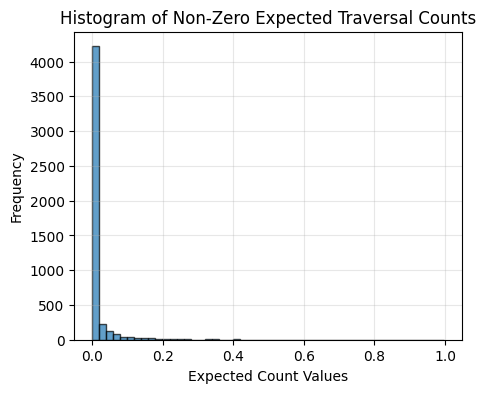

In [17]:
# Load the expected counts file
with open('../expected_counts_344344IBE31HW.pkl', 'rb') as f:
    expected_counts = pickle.load(f)

import matplotlib.pyplot as plt

# Get non-zero values from expected_counts
non_zero_values = expected_counts[expected_counts > 0]

print(f"Max value: {expected_counts.max()}")
print(f"Number of non-zero values: {len(non_zero_values)}")
print(f"Min non-zero value: {non_zero_values.min()}")

# Create histogram of non-zero values
plt.figure(figsize=(5, 4))
plt.hist(non_zero_values, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Expected Count Values')
plt.ylabel('Frequency')
plt.title('Histogram of Non-Zero Expected Traversal Counts')
plt.grid(True, alpha=0.3)
plt.show()

# <font color='red'>Cost</font>

In [ ]:
from equinox.dp.trespass.sparse_io_utils import load_sparse_coo_tensor_with_convention
try:
    edge_costs_tensor, interpretation_note = load_sparse_coo_tensor_with_convention(
        "../data/graph/V_soft/LEMD_EGLL_2023_04_01_COST_WIND.pt",
        target_device="cpu"
    ) # actually, sparse values are defaulted to 0 here (which is wrong, should be inf instead), but it does not matter because we never select these values during the sampling process
    print(f"Edge costs loaded. Interpretation Note: {interpretation_note}")
except FileNotFoundError:
    print("Edge costs file not found. Please run backward_svi first.")

In [ ]:
def print_edge_costs(edge_costs_tensor, node_to_idx, from_node, to_node):
    """
    Print all edge costs for transitions between two specific nodes.
    
    Args:
        edge_costs_tensor: Sparse tensor containing edge costs
        node_to_idx: Dictionary mapping node names to indices
        from_node: Source node name (string)
        to_node: Destination node name (string)
    """
    print(f"Edge costs tensor shape: {edge_costs_tensor.shape}")
    print(f"Number of non-zero entries: {edge_costs_tensor._nnz()}")
    print()

    # Extract indices and values
    indices = edge_costs_tensor.indices()  # Shape: (8, nnz)
    values = edge_costs_tensor.values()    # Shape: (nnz,)

    # Find entries where u_idx=from_node and v_idx=to_node
    mask = (indices[0] == node_to_idx[from_node]) & (indices[4] == node_to_idx[to_node])
    matching_indices = indices[:, mask]
    matching_values = values[mask]

    print(f"Found {matching_indices.shape[1]} transitions from node {from_node} to node {to_node}:")
    print()

    if matching_indices.shape[1] > 0:
        # Create a nicely formatted table
        print(f"{'u_idx':<6} {'k_u':<4} {'rho_u':<6} {'phi_u':<6} {'v_idx':<6} {'k_v':<4} {'rho_v':<6} {'phi_v':<6} {'cost':<10}")
        print("-" * 70)
        
        for i in range(matching_indices.shape[1]):
            u_idx = matching_indices[0, i].item()
            k_u = matching_indices[1, i].item()
            rho_u = matching_indices[2, i].item()
            phi_u = matching_indices[3, i].item()
            v_idx = matching_indices[4, i].item()
            k_v = matching_indices[5, i].item()
            rho_v = matching_indices[6, i].item()
            phi_v = matching_indices[7, i].item()
            cost = matching_values[i].item()
            
            print(f"{u_idx:<6} {k_u:<4} {rho_u:<6} {phi_u:<6} {v_idx:<6} {k_v:<4} {rho_v:<6} {phi_v:<6} {cost:<10.4f}")
    else:
        print(f"No transitions found from node {from_node} to node {to_node}")

# Call the function with LEMD to RBO
node_from_to_eval_cost = 'RBO'
node_to_eval_cost = 'SUSOS_49'
print_edge_costs(edge_costs_tensor, node_to_idx, node_from_to_eval_cost, node_to_eval_cost)


In [ ]:
# Find haversine distance between RBO and SUSOS_49
from equinox.helpers.haversine import haversine 
dist_between_nodes = haversine(G.nodes[node_from_to_eval_cost]['lat'], G.nodes[node_from_to_eval_cost]['lon'], G.nodes[node_to_eval_cost]['lat'], G.nodes[node_to_eval_cost]['lon'])
time_between_nodes = dist_between_nodes / (450 + (-101.24)) # use the wind average -101.24 from below, look up the RBO - SUSOS_49 in the Wind Averages section below
print(f"Time between RBO and SUSOS_49: {time_between_nodes} hours")
print(f"Predicted cost: {time_between_nodes * 0.5} (beta1=0.5)")

# Wind Averages

In [ ]:
import torch
wind_avg_path = "../data/graph/wind_averages/LEMD_EGLL_2023_04_01_wind_avg.pt"
wind_avg = torch.load(wind_avg_path)
print(f"Loaded wind averages tensor from {wind_avg_path} with shape {wind_avg.shape}")


In [ ]:
import torch
import numpy as np

def print_transitions_with_wind(
    transitions_list: list[tuple],
    idx_to_node: dict[int, str],
    avg_tailwind_knots_per_transition: torch.Tensor | None = None,
    node_to_filter_idx: int | None = None,
    mode: str = 'from'
):
    """
    Prints transitions in a padded table format.

    This function can optionally filter transitions by a specific node and display
    the tailwind for each transition. The original index of a transition, which is
    its index in `transitions_list`, is used to look up the corresponding tailwind
    from `avg_tailwind_knots_per_transition`.

    Args:
        transitions_list: A list of transition tuples.
        idx_to_node: A dictionary mapping node indices to node names.
        avg_tailwind_knots_per_transition: A tensor of tailwinds for each transition.
        node_to_filter_idx: If provided, only show transitions to/from this node index.
        mode: Either 'from' or 'to', to filter by departure or arrival node.
    """
    # Define column headers and widths
    headers = [
        "u_wp", "k_u_idx", "rho_u_idx", "alt_u", "phase_u",
        "v_wp", "k_v_idx", "rho_v_idx", "alt_v", "phase_v"
    ]
    col_widths = [7, 8, 10, 10, 8, 7, 8, 10, 10, 8]

    if avg_tailwind_knots_per_transition is not None:
        headers.append("tailwind")
        col_widths.append(10)
        
    # Phase mapping
    phase_map = {0: "CLB", 1: "CRZ", 2: "DES"}
    
    # Print header
    header_row = "".join(h.ljust(w) for h, w in zip(headers, col_widths))
    print(header_row)
    print("-" * sum(col_widths))

    # Print each matching transition in padded columns
    for i, transition in enumerate(transitions_list):
        u_idx, k_u_idx, rho_u_idx, u_alt_ft, phase_u, \
        v_idx, k_v_idx, rho_v_idx, v_alt_ft, phase_v = transition

        if node_to_filter_idx is not None:
            if mode == 'from':
                check_idx = u_idx
            elif mode == 'to':
                check_idx = v_idx
            else:
                raise ValueError(f"Invalid mode: {mode}")
            
            if check_idx != node_to_filter_idx:
                continue

        phase_u_str = phase_map.get(phase_u, str(phase_u))
        phase_v_str = phase_map.get(phase_v, str(phase_v))
        u_wp = idx_to_node.get(u_idx, str(u_idx))
        v_wp = idx_to_node.get(v_idx, str(v_idx))
        
        row = (
            f"{u_wp:<7}{k_u_idx:<8}{rho_u_idx:<10}"
            f"{u_alt_ft:<10.1f}{phase_u_str:<8}"
            f"{v_wp:<7}{k_v_idx:<8}{rho_v_idx:<10}"
            f"{v_alt_ft:<10.1f}{phase_v_str:<8}"
        )

        if avg_tailwind_knots_per_transition is not None:
            tailwind = avg_tailwind_knots_per_transition[i].item()
            row += f"{tailwind:<10.2f}"
            
        print(row)

node_to_inspect = 'RBO'
print(f"Transitions from {node_to_inspect} with tailwind:")
# Note: This assumes `avg_tailwind_knots_per_transition`, `transitions_closure_list`,
# and `node_to_idx` are already defined in your notebook's scope.
print_transitions_with_wind(
    transitions_list=thinned_closures,
    idx_to_node=idx_to_node,
    avg_tailwind_knots_per_transition=wind_avg,
    node_to_filter_idx=node_to_idx[node_to_inspect],
    mode='from'
)

---
# <font color='red'>Sampling statistics</font>

In [ ]:
import os
from collections import Counter, defaultdict
import numpy as np

def analyze_trajectory_occurrences(trajectory_file_path: str, return_type='probability'):
    """
    Analyze the occurrence (count or probability) and costs of each route.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file. Each line should be `cost,route`.
        return_type (str): Either 'count' for raw counts or 'probability' for normalized probabilities
        
    Returns:
        A tuple of (results, costs):
        - results (dict): Dictionary mapping trajectory strings to their occurrence counts or probabilities.
        - costs (dict): Dictionary mapping trajectory strings to a list of their costs.
    """
    if not os.path.exists(trajectory_file_path):
        print(f"Trajectory file not found: {trajectory_file_path}")
        return {}, {}
    
    routes = []
    costs = defaultdict(list)
    
    with open(trajectory_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            parts = line.split(',', 1)
            if len(parts) == 2:
                cost_str, route = parts
                routes.append(route)
                try:
                    costs[route].append(float(cost_str))
                except ValueError:
                    print(f"Warning: Could not parse cost '{cost_str}' for route. Skipping cost for this entry.")
            else:
                # Handle lines without a cost for backward compatibility
                routes.append(line)

    if not routes:
        print("No trajectories found in the file.")
        return {}, {}
    
    route_counts = Counter(routes)
    
    if return_type == 'count':
        results = dict(route_counts)
    elif return_type == 'probability':
        total_trajectories = len(routes)
        results = {
            route: count / total_trajectories 
            for route, count in route_counts.items()
        }
    else:
        raise ValueError("return_type must be either 'count' or 'probability'")
        
    return results, dict(costs)

def print_trajectory_analysis(trajectory_file_path: str, top_n: int = 10, return_type='probability'):
    """
    Print a formatted analysis of trajectory occurrences.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        top_n (int): Number of top trajectories to display
        return_type (str): Either 'count' for raw counts or 'probability' for normalized probabilities
    """
    results, costs = analyze_trajectory_occurrences(trajectory_file_path, return_type)
    
    if not results:
        return
    
    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
    
    total_trajectories = 0
    with open(trajectory_file_path, 'r') as f:
        total_trajectories = sum(1 for line in f if line.strip())

    total_unique = len(sorted_results)
    
    print(f"Trajectory Analysis Results:")
    print(f"Total trajectories: {total_trajectories}")
    print(f"Unique trajectories: {total_unique}")
    if total_trajectories > 0:
        print(f"Diversity ratio: {total_unique/total_trajectories:.3f}")
    print()
    
    unit = "Probability" if return_type == 'probability' else "Count"
    print(f"Top {min(top_n, len(sorted_results))} most frequent trajectories:")
    print(f"{'Rank':<5} {unit:<12} {'Ttl Cost':<12} {'Trajectory'}")
    print("-" * 90)
    
    for i, (trajectory, value) in enumerate(sorted_results[:top_n], 1):
        value_str = f"{value:.4f}" if return_type == 'probability' else str(value)
            
        total_cost_str = "N/A"
        if trajectory in costs and costs[trajectory]:
            total_cost = np.mean(costs[trajectory])
            total_cost_str = f"{total_cost:.2f}"
        
        display_trajectory = trajectory
        # if len(trajectory) > 50:
        #     waypoints = trajectory.split()
        #     if len(waypoints) > 8:
        #         display_trajectory = " ".join(waypoints[:3]) + " ... " + " ".join(waypoints[-3:])
        
        print(f"{i:<5} {value_str:<12} {total_cost_str:<12} {display_trajectory}")

def analyze_waypoint_frequencies(trajectory_file_path: str, exclude_endpoints=True):
    """
    Analyze the frequency of individual waypoints across all trajectories.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        exclude_endpoints (bool): Whether to exclude start and end nodes from the analysis
        
    Returns:
        A tuple of (waypoint_counts, total_trajectories)
    """
    if not os.path.exists(trajectory_file_path):
        print(f"Trajectory file not found: {trajectory_file_path}")
        return {}, 0
    
    waypoint_counts = Counter()
    total_trajectories = 0
    
    with open(trajectory_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                total_trajectories += 1
                
                parts = line.split(',', 1)
                route_str = parts[1] if len(parts) == 2 else line
                
                waypoints = route_str.split()
                
                if exclude_endpoints and len(waypoints) >= 2:
                    waypoints = waypoints[1:-1]
                
                waypoint_counts.update(waypoints)
    
    return dict(waypoint_counts), total_trajectories

def print_waypoint_analysis(trajectory_file_path: str, top_n: int = 15, exclude_endpoints=True):
    """
    Print a formatted analysis of waypoint frequencies.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        top_n (int): Number of top waypoints to display
        exclude_endpoints (bool): Whether to exclude start and end nodes from the analysis
    """
    waypoint_counts, total_trajectories = analyze_waypoint_frequencies(trajectory_file_path, exclude_endpoints)
    
    if not waypoint_counts:
        return
    
    sorted_waypoints = sorted(waypoint_counts.items(), key=lambda x: x[1], reverse=True)
    
    print(f"Waypoint Frequency Analysis:")
    print(f"Total trajectories analyzed: {total_trajectories}")
    print(f"Endpoints {'excluded' if exclude_endpoints else 'included'}")
    print()
    
    print(f"Top {min(top_n, len(sorted_waypoints))} most frequent waypoints:")
    print(f"{'Rank':<5} {'Waypoint':<15} {'Count':<8} {'Frequency':<10}")
    print("-" * 45)
    
    for i, (waypoint, count) in enumerate(sorted_waypoints[:top_n], 1):
        if total_trajectories > 0:
            frequency = count / total_trajectories
            print(f"{i:<5} {waypoint:<15} {count:<8} {frequency:.3f}")

# Example usage
trajectory_file = '../data/graph/trajectories/LEMD_EGLL_2023_04_01_CLB_trajectories.txt'

print("=== TRAJECTORY OCCURRENCE ANALYSIS ===")
print_trajectory_analysis(trajectory_file, top_n=20, return_type='probability')

print("\n" + "="*60 + "\n")

print("=== WAYPOINT FREQUENCY ANALYSIS ===")
print_waypoint_analysis(trajectory_file, top_n=15, exclude_endpoints=True)


In [ ]:
import os
from collections import Counter
import numpy as np

def analyze_route_segments(trajectory_file_path: str, segment_length: int = 2):
    """
    Analyze the frequency of route segments (consecutive waypoint sequences) in trajectories.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        segment_length (int): Length of segments to analyze (e.g., 2 for pairs, 3 for triplets)
        
    Returns:
        dict: Dictionary mapping segment tuples to their occurrence counts
    """
    if not os.path.exists(trajectory_file_path):
        print(f"Trajectory file not found: {trajectory_file_path}")
        return {}
    
    segment_counts = Counter()
    
    with open(trajectory_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(',', 1)
            route_str = parts[1] if len(parts) == 2 else line
            
            waypoints = route_str.split()
            # Extract all segments of the specified length
            for i in range(len(waypoints) - segment_length + 1):
                segment = tuple(waypoints[i:i + segment_length])
                segment_counts[segment] += 1
    
    return dict(segment_counts)

def print_segment_analysis(trajectory_file_path: str, segment_length: int = 2, top_n: int = 15):
    """
    Print a formatted analysis of route segment frequencies.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        segment_length (int): Length of segments to analyze
        top_n (int): Number of top segments to display
    """
    segment_counts = analyze_route_segments(trajectory_file_path, segment_length)
    
    if not segment_counts:
        return
    
    sorted_segments = sorted(segment_counts.items(), key=lambda x: x[1], reverse=True)
    
    total_segments = sum(segment_counts.values())
    
    print(f"Route Segment Analysis (length {segment_length}):")
    print(f"Total segments: {total_segments}")
    print(f"Unique segments: {len(sorted_segments)}")
    print()
    
    print(f"Top {min(top_n, len(sorted_segments))} most frequent segments:")
    print(f"{'Rank':<5} {'Count':<8} {'Frequency':<10} {'Segment'}")
    print("-" * 60)
    
    for i, (segment, count) in enumerate(sorted_segments[:top_n], 1):
        if total_segments > 0:
            frequency = count / total_segments
            segment_str = " -> ".join(segment)
            print(f"{i:<5} {count:<8} {frequency:.3f}     {segment_str}")

def get_trajectory_statistics(trajectory_file_path: str):
    """
    Get basic statistics about the trajectories, including costs.
    
    Args:
        trajectory_file_path (str): Path to the trajectory file
        
    Returns:
        dict: Dictionary containing various statistics
    """
    if not os.path.exists(trajectory_file_path):
        print(f"Trajectory file not found: {trajectory_file_path}")
        return {}
    
    trajectory_lengths = []
    trajectory_costs = []
    unique_routes = set()
    
    with open(trajectory_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(',', 1)
            if len(parts) == 2:
                cost_str, route_str = parts
                try:
                    trajectory_costs.append(float(cost_str))
                except ValueError:
                    print(f"Warning: Could not parse cost '{cost_str}'.")
            else:
                route_str = line
            
            waypoints = route_str.split()
            trajectory_lengths.append(len(waypoints))
            unique_routes.add(route_str)
    
    if not trajectory_lengths:
        return {}
    
    stats = {
        'total_trajectories': len(trajectory_lengths),
        'unique_trajectories': len(unique_routes),
        'diversity_ratio': len(unique_routes) / len(trajectory_lengths) if trajectory_lengths else 0,
        'avg_length': np.mean(trajectory_lengths),
        'median_length': np.median(trajectory_lengths),
        'min_length': np.min(trajectory_lengths),
        'max_length': np.max(trajectory_lengths),
        'std_length': np.std(trajectory_lengths)
    }
    
    if trajectory_costs:
        stats.update({
            'avg_cost': np.mean(trajectory_costs),
            'median_cost': np.median(trajectory_costs),
            'min_cost': np.min(trajectory_costs),
            'max_cost': np.max(trajectory_costs),
            'std_cost': np.std(trajectory_costs)
        })
    
    return stats

def print_trajectory_statistics(trajectory_file_path: str):
    """
    Print comprehensive statistics about the trajectories.
    """
    stats = get_trajectory_statistics(trajectory_file_path)
    
    if not stats:
        return
    
    print("Trajectory Statistics:")
    print("=" * 30)
    print(f"Total trajectories:     {stats['total_trajectories']}")
    print(f"Unique trajectories:    {stats['unique_trajectories']}")
    print(f"Diversity ratio:        {stats['diversity_ratio']:.3f}")
    print()
    print("Trajectory Length Statistics:")
    print(f"Average length:         {stats['avg_length']:.2f}")
    print(f"Median length:          {stats['median_length']:.1f}")
    print(f"Min length:             {stats['min_length']}")
    print(f"Max length:             {stats['max_length']}")
    print(f"Standard deviation:     {stats['std_length']:.2f}")

    if 'avg_cost' in stats:
        print()
        print("Trajectory Cost Statistics:")
        print(f"Average cost:           {stats['avg_cost']:.2f}")
        print(f"Median cost:            {stats['median_cost']:.2f}")
        print(f"Min cost:               {stats['min_cost']:.2f}")
        print(f"Max cost:               {stats['max_cost']:.2f}")
        print(f"Standard deviation:     {stats['std_cost']:.2f}")

# Example usage (assuming trajectory_file is defined from the previous cell)
trajectory_file = '../data/graph/trajectories/LEMD_EGLL_2023_04_01_CLB_trajectories.txt'

print("=== TRAJECTORY STATISTICS ===")
print_trajectory_statistics(trajectory_file)

print("\n" + "="*60 + "\n")

print("=== ROUTE SEGMENT ANALYSIS (Pairs) ===")
print_segment_analysis(trajectory_file, segment_length=2, top_n=10)

print("\n" + "="*60 + "\n")

print("=== ROUTE SEGMENT ANALYSIS (Triplets) ===")
print_segment_analysis(trajectory_file, segment_length=3, top_n=10)

In [ ]:
from equinox.helpers.plotters import plot_routes_on_map
"""
Plot the 10 most-frequent LEMD→EGLL routes for 2023-04-01.

Assumptions
-----------
• The waypoint graph (nodes carry 'lat' and 'lon' attributes) is
  stored at ../data/graph/airways_graph.gpickle.  Adjust the path
  to whatever graph file you have.
• The trajectory file is exactly the one named below and each line
  is of the form:
      <cost>,<origin WP> <WP1> <WP2> … <destination WP>
"""

import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import cartopy.crs as ccrs

from equinox.helpers.plotters import plot_routes_on_map   # provided helper

# ----------------------------------------------------------------------
# 2. Parse trajectory file and count identical routes
# ----------------------------------------------------------------------
traj_file = "../data/graph/trajectories/LEMD_EGLL_2023_04_01_CLB_trajectories.txt"

route_counter: Counter[str] = Counter()

with open(traj_file, "r", encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue                                              # skip blanks
        try:
            _, route = line.split(",", 1)                         # ignore cost
        except ValueError:
            print(f"Skipping malformed line: {line!r}")
            continue
        # Canonicalise the route string so that identical waypoint sequences
        # are treated the same in the counter.
        canonical = " ".join(route.split())                       # squash spaces
        route_counter[canonical] += 1

# ----------------------------------------------------------------------
# 3. Select the ten most-frequent routes
# ----------------------------------------------------------------------
top_10_routes = [route_str.split() for route_str, _ in route_counter.most_common(10)]

print("Top-10 routes (most-to-least frequent):")
for idx, r in enumerate(top_10_routes, 1):
    print(f"{idx:2d}. {' → '.join(r)}")

import xarray as xr
import numpy as np                        #  NEW
# ----------------------------------------------------------------------
# 0.  Open the wind data set
# ----------------------------------------------------------------------
era_file = "../data/era5/2024-04-01.nc"  # adjust if needed
ds       = xr.open_dataset(era_file)

time_dim  = "valid_time" if "valid_time" in ds.dims else "time"
level_dim = "pressure_level"             # ERA5 pressure-level name
u_var, v_var = "u", "v"                  # change to 'u10'/'v10' for 10-m winds

u = ds[u_var].isel({time_dim: 10, level_dim: 0})   # pressure-level 0, time 0
v = ds[v_var].isel({time_dim: 10, level_dim: 0})
speed = np.sqrt(u**2 + v**2)

# ----------------------------------------------------------------------
# 1.  Plot wind-speed field first (so routes are drawn on top)
# ----------------------------------------------------------------------
fig = plt.figure(figsize=(48, 16))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

cmap_levels = np.linspace(0, speed.max().values, 21)      # 20 equally spaced levels
cf = ax.contourf(u.longitude, u.latitude, speed, 
                 levels=cmap_levels,
                 cmap="viridis",
                 alpha=0.6,                        # see-through shading
                 transform=ccrs.PlateCarree(),
                 zorder=1)                        # beneath route lines

cbar = fig.colorbar(cf, ax=ax, orientation="vertical",
                    label="Wind speed (m s⁻¹)")

# Add wind direction quivers on top of the wind speed field

# Subsample the wind field for quiver plotting to avoid overplotting
quiver_step = 2  # adjust for density; higher = sparser
lon_2d, lat_2d = np.meshgrid(u.longitude.values, u.latitude.values)

# Subsample arrays
lon_sub = lon_2d[::quiver_step, ::quiver_step]
lat_sub = lat_2d[::quiver_step, ::quiver_step]
u_sub = u.values[::quiver_step, ::quiver_step]
v_sub = v.values[::quiver_step, ::quiver_step]

# Plot quivers (wind barbs) for direction
q = ax.quiver(
    lon_sub, lat_sub, u_sub, v_sub,
    scale=700, width=0.003, headwidth=3, headlength=4,
    color='white', alpha=0.7, zorder=2, transform=ccrs.PlateCarree()
)


# ----------------------------------------------------------------------
# 2.  Now draw the routes on top
# ----------------------------------------------------------------------
plot_routes_on_map(G, top_10_routes, ax=ax)   # helper already imported

ax.set_title("Top-10 Predicted LEMD → EGLL Routes (2023-04-01)\n"
             "with Wind Field Overlay (CRZ/200mbar) 10:00 UTC")
plt.legend()
plt.show()